In [22]:

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import train_test_split

data_path = Path("TRAIN2.xlsx")
model_path = Path("final_score_model.joblib")
meta_path = Path("model_meatadata.json")

plt.rcParams["figure.figsize"] = (8,5)

In [23]:
df = pd.read_excel(data_path)
df.columns = [str(c).strip().lower() for c in df.columns]

print("Kich thuoc du lieu: ", df.shape)
display(df.head())
display(df.describe())

Kich thuoc du lieu:  (515, 2)


,final,midterm
0,2.56,0.70
1,2.78,0.97
2,6.35,5.43
3,5.99,4.99
4,7.67,7.09


,final,midterm
count,515.000000,515.000000
mean,6.032544,5.038136
std,2.343196,2.928851
min,2.030000,0.030000
25%,3.910000,2.385000
50%,6.030000,5.040000
75%,8.085000,7.605000
max,9.970000,9.960000


In [24]:
target_col = "final"
feature_col = "midterm"

require_cols = {target_col, feature_col}
missing_cols = require_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Thiếu cột: {missing_cols}. Các cột hiện có: {list(df.columns)}")

# Làm sạch dữ liệu
data = df[[target_col, feature_col]].copy()
data[target_col] = pd.to_numeric(data[target_col], errors="coerce")
data[feature_col] = pd.to_numeric(data[feature_col], errors="coerce")
data = data.dropna().reset_index(drop=True)

# Điểm thường nằm trong khoảng 0-10; clip nhẹ để tránh giá trị ngoại lai do nhập sai.
data[target_col] = data[target_col].clip(0, 10)
data[feature_col] = data[feature_col].clip(0, 10)

print("Số dòng sau khi làm sạch:", len(data))
display(data.head())

Số dòng sau khi làm sạch: 515


,final,midterm
0,2.56,0.70
1,2.78,0.97
2,6.35,5.43
3,5.99,4.99
4,7.67,7.09


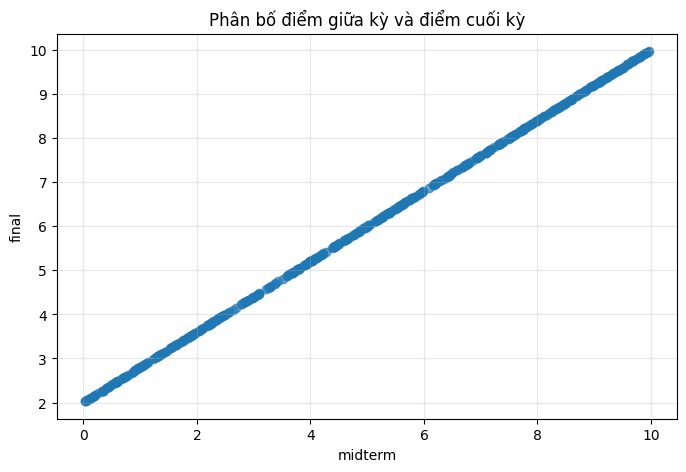

Hệ số tương quan Pearson giữa midterm và final: 0.999999


In [25]:
plt.figure()
plt.scatter(data[feature_col], data[target_col], alpha=0.65)
plt.xlabel("midterm")
plt.ylabel("final")
plt.title("Phân bố điểm giữa kỳ và điểm cuối kỳ")
plt.grid(True, alpha=0.3)
plt.show()

corr = data[[feature_col, target_col]].corr().iloc[0, 1]
print(f"Hệ số tương quan Pearson giữa midterm và final: {corr:.6f}")

## Train Model

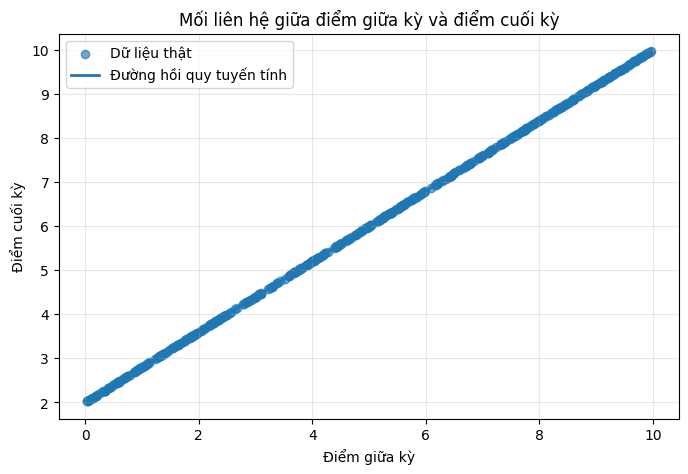

Công thức mô hình học được: 
final_pred = 2.001655 + 0.800071 * midterm


In [34]:
X = data[[feature_col]]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

b0 = float(model.intercept_)
b1 = float(model.coef_[0])

# Tạo các giá trị x liên tục từ min đến max của điểm giữa kỳ
x_line = np.linspace(
    data[feature_col].min(),
    data[feature_col].max(),
    200
).reshape(-1, 1)

# Dự đoán y tương ứng theo mô hình đã train
y_line = model.predict(
    pd.DataFrame(x_line, columns=[feature_col])
)

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))

# Scatter plot dữ liệu thật
plt.scatter(
    data[feature_col],
    data[target_col],
    alpha=0.65,
    label="Dữ liệu thật"
)

# Đường hồi quy tuyến tính
plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Đường hồi quy tuyến tính"
)

plt.xlabel("Điểm giữa kỳ")
plt.ylabel("Điểm cuối kỳ")
plt.title("Mối liên hệ giữa điểm giữa kỳ và điểm cuối kỳ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Công thức mô hình học được: ")
print(f"final_pred = {b0:.6f} + {b1:.6f} * midterm")

In [27]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})
display(metrics)

,Metric,Value
0,MAE,0.002419
1,RMSE,0.002815
2,R2,0.999998


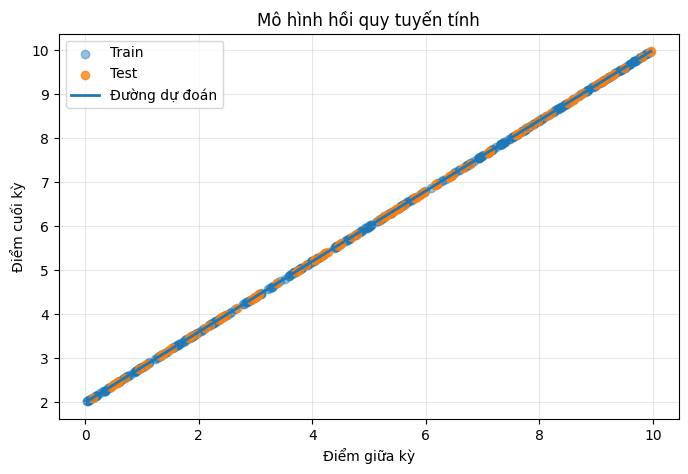

In [28]:
x_line = np.linspace(data[feature_col].min(), data[feature_col].max(), 200).reshape(-1, 1)
y_line = model.predict(pd.DataFrame(x_line, columns=[feature_col]))

plt.figure()
plt.scatter(X_train[feature_col], y_train, alpha=0.45, label="Train")
plt.scatter(X_test[feature_col], y_test, alpha=0.75, label="Test")
plt.plot(x_line, y_line, linewidth=2, label="Đường dự đoán")
plt.xlabel("Điểm giữa kỳ")
plt.ylabel("Điểm cuối kỳ")
plt.title("Mô hình hồi quy tuyến tính")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

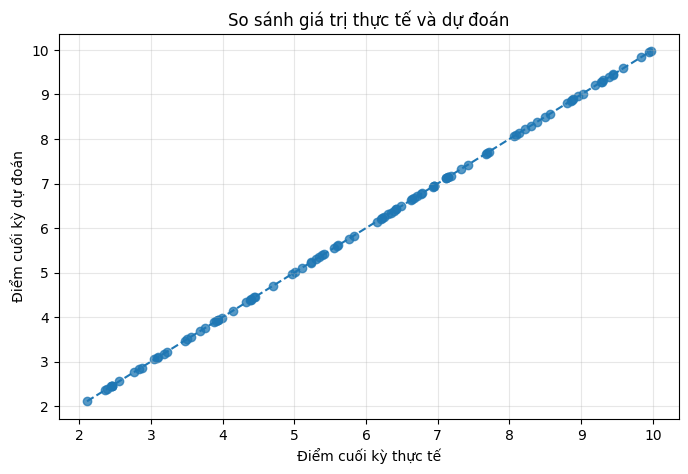

In [29]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.75)
min_score = min(y_test.min(), y_pred.min())
max_score = max(y_test.max(), y_pred.max())
plt.plot([min_score, max_score], [min_score, max_score], linestyle="--")
plt.xlabel("Điểm cuối kỳ thực tế")
plt.ylabel("Điểm cuối kỳ dự đoán")
plt.title("So sánh giá trị thực tế và dự đoán")
plt.grid(True, alpha=0.3)
plt.show()

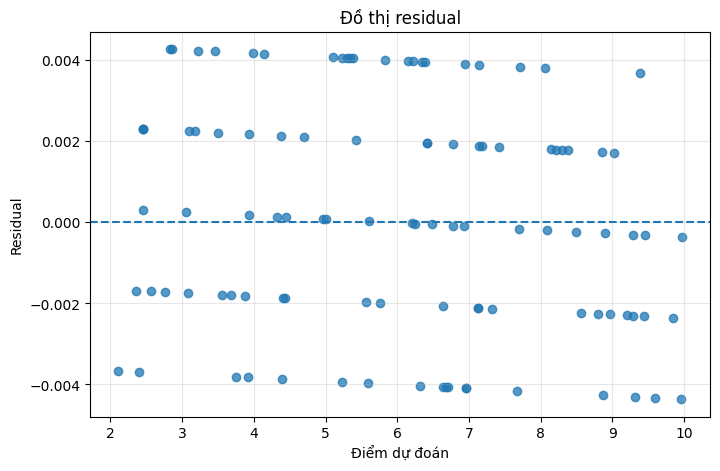

In [30]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, alpha=0.75)
plt.axhline(0, linestyle="--")
plt.xlabel("Điểm dự đoán")
plt.ylabel("Residual")
plt.title("Đồ thị residual")
plt.grid(True, alpha=0.3)
plt.show()

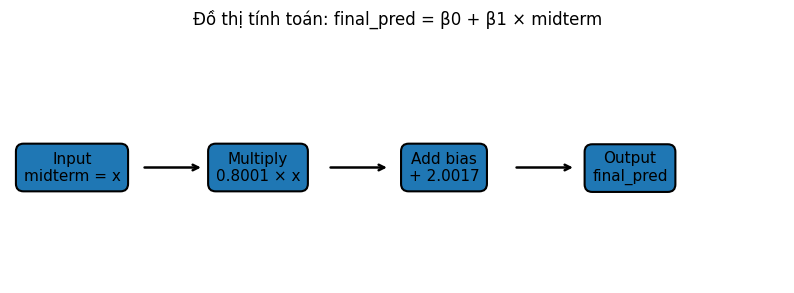

In [31]:
def draw_computation_graph(b0, b1):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis("off")

    boxes = [
        (0.08, 0.5, "Input\nmidterm = x"),
        (0.32, 0.5, f"Multiply\n{b1:.4f} × x"),
        (0.56, 0.5, f"Add bias\n+ {b0:.4f}"),
        (0.80, 0.5, "Output\nfinal_pred"),
    ]

    for x, y, text in boxes:
        ax.text(
            x, y, text,
            ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.5", linewidth=1.5)
        )

    for start, end in [(0.17, 0.25), (0.41, 0.49), (0.65, 0.73)]:
        ax.annotate("", xy=(end, 0.5), xytext=(start, 0.5), arrowprops=dict(arrowstyle="->", lw=1.8))

    ax.set_title("Đồ thị tính toán: final_pred = β0 + β1 × midterm", pad=20)
    plt.show()

draw_computation_graph(b0, b1)

### Thử dự đoán sử dụng mô hình 

In [32]:
def predict_final(midterm_score: float) -> float:
    midterm_score = np.clip(midterm_score, 0, 10)
    pred = model.predict(pd.DataFrame({feature_col: [midterm_score]}))[0]
    return float(np.clip(pred, 0, 10))

sample_midterm = 3.6
print(f"Điểm giữa kỳ: {sample_midterm}")
print(f"Điểm cuối kỳ dự đoán: {predict_final(sample_midterm):.2f}")

Điểm giữa kỳ: 3.6
Điểm cuối kỳ dự đoán: 4.88


In [33]:
# Huấn luyện lại trên toàn bộ dữ liệu để tận dụng đủ dataset trước khi lưu.
final_model = LinearRegression()
final_model.fit(X, y)

final_b0 = float(final_model.intercept_)
final_b1 = float(final_model.coef_[0])

joblib.dump(final_model, model_path)

metadata = {
    "feature_col": feature_col,
    "target_col": target_col,
    "formula": f"final_pred = {final_b0:.6f} + {final_b1:.6f} * midterm",
    "intercept": final_b0,
    "coef_midterm": final_b1,
    "train_rows": int(len(data)),
    "test_mae": float(mae),
    "test_rmse": float(rmse),
    "test_r2": float(r2),
}
meta_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print("Đã lưu:", model_path)
print("Đã lưu:", meta_path)
print(metadata["formula"])

Đã lưu: final_score_model.joblib
Đã lưu: model_meatadata.json
final_pred = 2.001839 + 0.800039 * midterm
